# Exploratory Data Analysis — StatApp Database

**Objective:** Perform a comprehensive exploratory data analysis (EDA) of the three main tables in the StatApp SQLite database — `clients`, `dossiers`, and `transactions` — and derive actionable insights.

**Database summary:**
| Table | Rows | Columns | Description |
|-------|------|---------|-------------|
| `clients` | 5 000 | 13 | Customer demographics and relationship data |
| `dossiers` | 10 000 | 15 | Financial product applications (loans, savings, etc.) |
| `transactions` | 50 000 | 14 | Debit transactions across partner retailers |

**Time period covered:** December 2020 – December 2025

In [1]:
import sqlite3
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.1)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.2f}".format)

%matplotlib inline

## 1. Data Loading

In [2]:
DB_PATH = os.path.join("data", "statapp.sqlite")
conn = sqlite3.connect(DB_PATH)

clients = pd.read_sql("SELECT * FROM clients", conn)
dossiers = pd.read_sql("SELECT * FROM dossiers", conn)
transactions = pd.read_sql("SELECT * FROM transactions", conn)

# Convert date columns
for col in ["date_naissance", "date_entree_relation", "date_maj"]:
    clients[col] = pd.to_datetime(clients[col])

for col in ["date_demande", "date_decision", "date_maj"]:
    dossiers[col] = pd.to_datetime(dossiers[col])

for col in ["date_transaction", "datetime_transaction"]:
    transactions[col] = pd.to_datetime(transactions[col])

print(f"clients:       {clients.shape}")
print(f"dossiers:      {dossiers.shape}")
print(f"transactions:  {transactions.shape}")

clients:       (5000, 13)
dossiers:      (10000, 15)
transactions:  (50000, 14)


## 2. Data Overview

### 2.1 Clients table

In [3]:
clients.info()
clients.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype              
---  ------                    --------------  -----              
 0   client_id                 5000 non-null   str                
 1   civilite                  5000 non-null   str                
 2   nom                       5000 non-null   str                
 3   prenom                    5000 non-null   str                
 4   date_naissance            5000 non-null   datetime64[us]     
 5   code_postal               5000 non-null   int64              
 6   commune                   5000 non-null   str                
 7   date_entree_relation      5000 non-null   datetime64[us]     
 8   anciennete_mois           5000 non-null   int64              
 9   segment_client            5000 non-null   str                
 10  score_client_fragile      5000 non-null   int64              
 11  carte_fidelite_carrefour  50

,client_id,civilite,nom,prenom,date_naissance,code_postal,commune,date_entree_relation,anciennete_mois,segment_client,score_client_fragile,carte_fidelite_carrefour,date_maj
count,5000,5000,5000,5000,5000,5000.00,5000,5000,5000.00,5000,5000.00,5000.00,5000
unique,5000,2,57,56,NaN,NaN,37,NaN,NaN,3,NaN,NaN,NaN
top,CLI000486,M,Diop,Nicolas,NaN,NaN,Amiens,NaN,NaN,BRONZE,NaN,NaN,NaN
freq,1,3060,108,109,NaN,NaN,166,NaN,NaN,2567,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,1976-07-19 13:27:33.120000,51448.86,NaN,2023-06-04 13:08:49.920000,30.39,NaN,489.63,0.70,2025-12-05 21:34:44.337751+00:00
min,NaN,NaN,NaN,NaN,1951-12-05 00:00:00,6000.00,NaN,2020-12-07 00:00:00,0.00,NaN,0.00,0.00,2025-12-05 21:34:44.337751+00:00
25%,NaN,NaN,NaN,NaN,1963-12-05 00:00:00,33000.00,NaN,2022-02-28 00:00:00,16.00,NaN,316.00,0.00,2025-12-05 21:34:44.337751+00:00
50%,NaN,NaN,NaN,NaN,1975-12-05 00:00:00,51100.00,NaN,2023-06-06 00:00:00,30.00,NaN,491.00,1.00,2025-12-05 21:34:44.337751+00:00
75%,NaN,NaN,NaN,NaN,1988-12-05 00:00:00,69100.00,NaN,2024-08-31 00:00:00,46.00,NaN,654.00,1.00,2025-12-05 21:34:44.337751+00:00
max,NaN,NaN,NaN,NaN,2000-12-05 00:00:00,95100.00,NaN,2025-12-05 00:00:00,60.00,NaN,899.00,1.00,2025-12-05 21:34:44.337751+00:00


### 2.2 Dossiers table

In [4]:
dossiers.info()
dossiers.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   dossier_id                 10000 non-null  str                
 1   client_id                  10000 non-null  str                
 2   type_produit               10000 non-null  str                
 3   montant                    10000 non-null  int64              
 4   duree_mois                 4009 non-null   float64            
 5   taux_annuel                4009 non-null   float64            
 6   date_demande               10000 non-null  datetime64[us]     
 7   date_decision              10000 non-null  datetime64[us]     
 8   statut_acceptation         10000 non-null  str                
 9   statut_dossier             8498 non-null   str                
 10  solde_restant_du           4009 non-null   float64            
 11  nombre_echeanc

,dossier_id,client_id,type_produit,montant,duree_mois,taux_annuel,date_demande,date_decision,statut_acceptation,statut_dossier,solde_restant_du,nombre_echeances_payees,nombre_incidents_paiement,canal_souscription,date_maj
count,10000,10000,10000,10000.00,4009.00,4009.00,10000,10000,10000,8498,4009.00,4009.00,10000.00,10000,10000
unique,10000,4326,5,NaN,NaN,NaN,NaN,NaN,2,3,NaN,NaN,NaN,3,NaN
top,DOS0000039,CLI001190,CTE,NaN,NaN,NaN,NaN,NaN,ACCEPTE,EN_COURS,NaN,NaN,NaN,MAGASIN,NaN
freq,1,9,4001,NaN,NaN,NaN,NaN,NaN,8498,5956,NaN,NaN,NaN,5015,NaN
mean,NaN,NaN,NaN,10695.94,31.70,4.89,2024-06-05 15:17:25.440000,2024-06-13 17:06:00,NaN,NaN,8366.17,18.34,0.30,NaN,2025-12-05 21:52:13.542660+00:00
min,NaN,NaN,NaN,1000.00,6.00,2.50,2022-12-07 00:00:00,2022-12-09 00:00:00,NaN,NaN,1055.67,1.00,0.00,NaN,2025-12-05 21:52:13.542661+00:00
25%,NaN,NaN,NaN,4972.00,12.00,4.00,2023-09-07 00:00:00,2023-09-15 00:00:00,NaN,NaN,4648.30,9.00,0.00,NaN,2025-12-05 21:52:13.542661+00:00
50%,NaN,NaN,NaN,8445.00,24.00,4.80,2024-06-02 00:00:00,2024-06-11 00:00:00,NaN,NaN,7347.06,18.00,0.00,NaN,2025-12-05 21:52:13.542661+00:00
75%,NaN,NaN,NaN,14849.50,48.00,5.80,2025-03-09 00:00:00,2025-03-19 00:00:00,NaN,NaN,11410.62,27.00,0.00,NaN,2025-12-05 21:52:13.542661+00:00
max,NaN,NaN,NaN,39990.00,60.00,7.90,2025-12-05 00:00:00,2025-12-19 00:00:00,NaN,NaN,22231.31,36.00,3.00,NaN,2025-12-05 21:52:13.542661+00:00


### 2.3 Transactions table

In [5]:
transactions.info()
transactions.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   transaction_id        50000 non-null  str                
 1   dossier_id            50000 non-null  str                
 2   client_id             50000 non-null  str                
 3   date_transaction      50000 non-null  datetime64[us]     
 4   datetime_transaction  50000 non-null  datetime64[us, UTC]
 5   type_transaction      50000 non-null  str                
 6   montant               50000 non-null  float64            
 7   sens                  50000 non-null  str                
 8   libelle               50000 non-null  str                
 9   enseigne              50000 non-null  str                
 10  in_out_carrefour      50000 non-null  str                
 11  categorie_achat       50000 non-null  str                
 12  statut_transact

,transaction_id,dossier_id,client_id,date_transaction,datetime_transaction,type_transaction,montant,sens,libelle,enseigne,in_out_carrefour,categorie_achat,statut_transaction,pays
count,50000,50000,50000,50000,50000,50000,50000.00,50000,50000,50000,50000,50000,50000,50000
unique,50000,5093,3204,NaN,NaN,2,NaN,1,37,37,2,9,2,6
top,TRX0000003539,DOS0007791,CLI004271,NaN,NaN,PRELEVEMENT,NaN,DEBIT,RETRAIT DAB,DAB,IN,ALIMENTAIRE,VALIDEE,FR
freq,1,23,72,NaN,NaN,42571,NaN,50000,7429,7429,25344,20522,48457,47513
mean,NaN,NaN,NaN,2025-03-08 04:42:28.224000,2025-03-08 19:13:35.544000+00:00,NaN,109.82,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,2022-12-20 00:00:00,2022-12-20 21:00:00+00:00,NaN,10.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,2024-10-11 00:00:00,2024-10-11 11:00:00+00:00,NaN,60.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,2025-05-17 00:00:00,2025-05-17 13:30:00+00:00,NaN,110.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,2025-09-26 00:00:00,2025-09-26 08:00:00+00:00,NaN,160.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,2025-12-18 00:00:00,2025-12-18 21:00:00+00:00,NaN,209.99,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2.4 Missing-Value Analysis

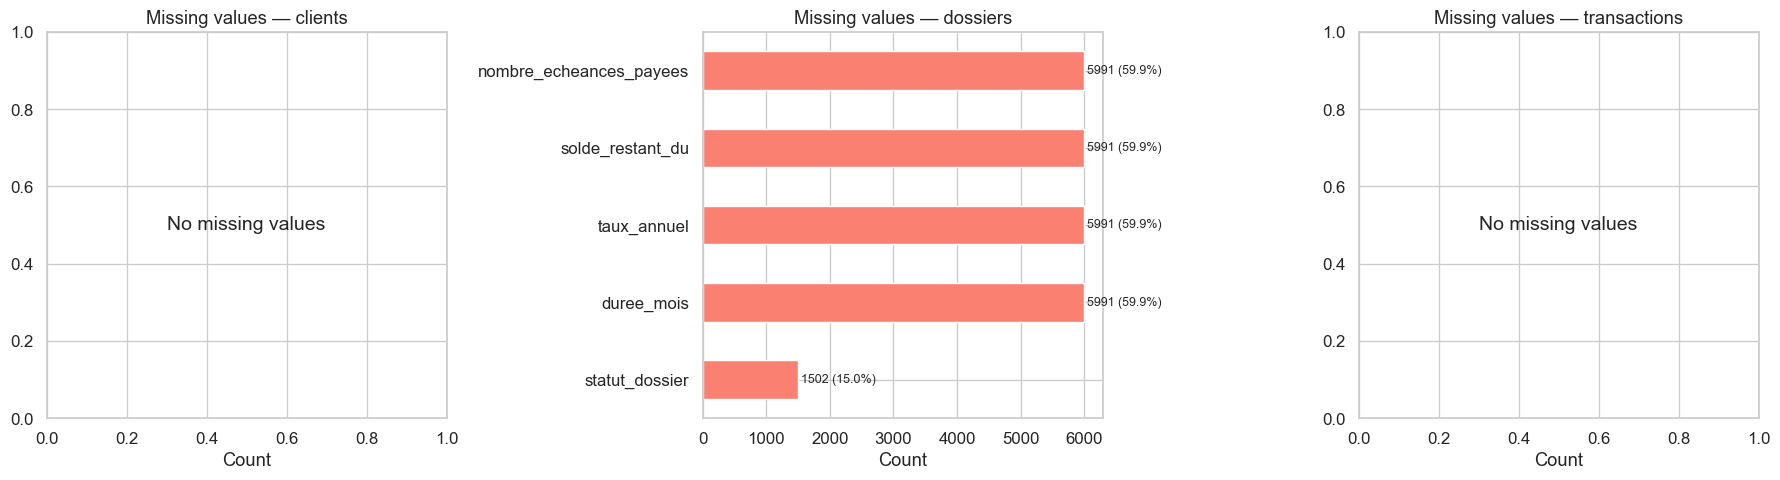

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, df) in zip(axes, [("clients", clients), ("dossiers", dossiers), ("transactions", transactions)]):
    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=True)
    if len(missing) == 0:
        ax.text(0.5, 0.5, "No missing values", ha="center", va="center", fontsize=14)
    else:
        missing.plot.barh(ax=ax, color="salmon")
        for i, v in enumerate(missing):
            ax.text(v + 50, i, f"{v} ({100*v/len(df):.1f}%)", va="center", fontsize=9)
    ax.set_title(f"Missing values — {name}")
    ax.set_xlabel("Count")

plt.tight_layout()
plt.show()

**Interpretation — Missing values:**
- **Clients** and **transactions**: no missing values.
- **Dossiers**: the columns `duree_mois`, `taux_annuel`, `solde_restant_du`, and `nombre_echeances_payees` are all null in ~60 % of rows. These correspond to non-credit products (e.g. CPP, PAT) where loan-specific fields are inapplicable. This is **structurally expected**, not data-quality noise.
- `statut_dossier` is null for ~15 % of rows — these are recently refused applications that have no lifecycle status yet.

## 3. Clients — Exploratory Analysis

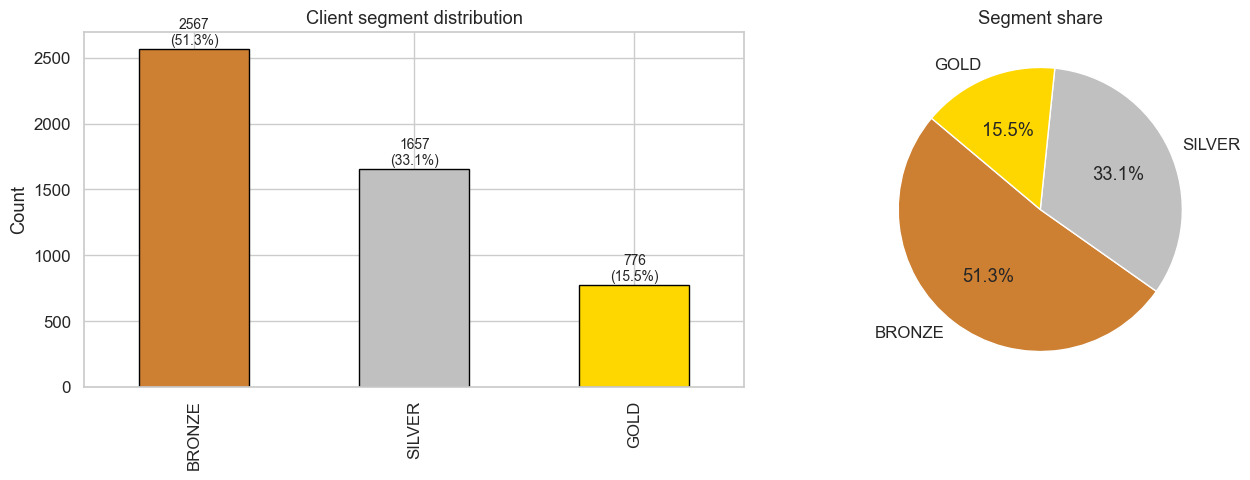

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
seg_counts = clients["segment_client"].value_counts()
seg_counts.plot.bar(ax=axes[0], color=["#cd7f32", "#c0c0c0", "#ffd700"], edgecolor="black")
axes[0].set_title("Client segment distribution")
axes[0].set_ylabel("Count")
axes[0].set_xlabel("")
for i, v in enumerate(seg_counts):
    axes[0].text(i, v + 30, f"{v}\n({100*v/len(clients):.1f}%)", ha="center", fontsize=10)

# Pie chart
seg_counts.plot.pie(ax=axes[1], autopct="%1.1f%%", startangle=140,
                     colors=["#cd7f32", "#c0c0c0", "#ffd700"])
axes[1].set_ylabel("")
axes[1].set_title("Segment share")

plt.tight_layout()
plt.show()

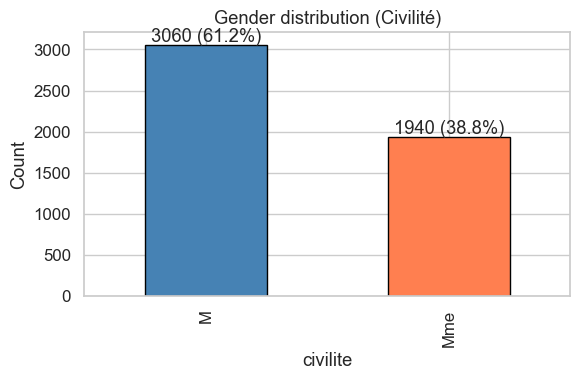

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
civ = clients["civilite"].value_counts()
civ.plot.bar(ax=ax, color=["steelblue", "coral"], edgecolor="black")
ax.set_title("Gender distribution (Civilité)")
ax.set_ylabel("Count")
for i, v in enumerate(civ):
    ax.text(i, v + 30, f"{v} ({100*v/len(clients):.1f}%)", ha="center")
plt.tight_layout()
plt.show()

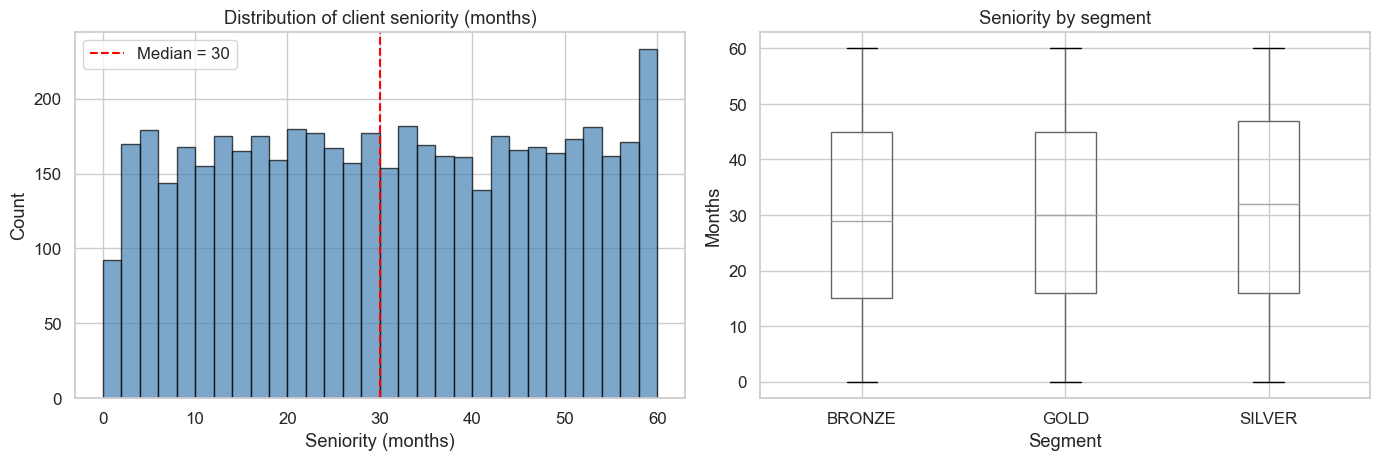

                 count  mean   std  min   25%   50%   75%   max
segment_client                                                 
BRONZE         2567.00 29.70 17.30 0.00 15.00 29.00 45.00 60.00
GOLD            776.00 30.70 17.50 0.00 16.00 30.00 45.00 60.00
SILVER         1657.00 31.30 17.30 0.00 16.00 32.00 47.00 60.00


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

clients["anciennete_mois"].hist(bins=30, ax=axes[0], color="steelblue", edgecolor="black", alpha=0.7)
axes[0].set_title("Distribution of client seniority (months)")
axes[0].set_xlabel("Seniority (months)")
axes[0].set_ylabel("Count")
axes[0].axvline(clients["anciennete_mois"].median(), color="red", linestyle="--", label=f'Median = {clients["anciennete_mois"].median():.0f}')
axes[0].legend()

clients.boxplot(column="anciennete_mois", by="segment_client", ax=axes[1])
axes[1].set_title("Seniority by segment")
axes[1].set_xlabel("Segment")
axes[1].set_ylabel("Months")
plt.suptitle("")

plt.tight_layout()
plt.show()

print(clients.groupby("segment_client")["anciennete_mois"].describe().round(1))

/var/folders/5g/qf_vww7d3vl8k5x593qbwpzw0000gn/T/ipykernel_26455/2611643435.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=clients, x="segment_client", y="score_client_fragile", ax=axes[1], palette="Set2")


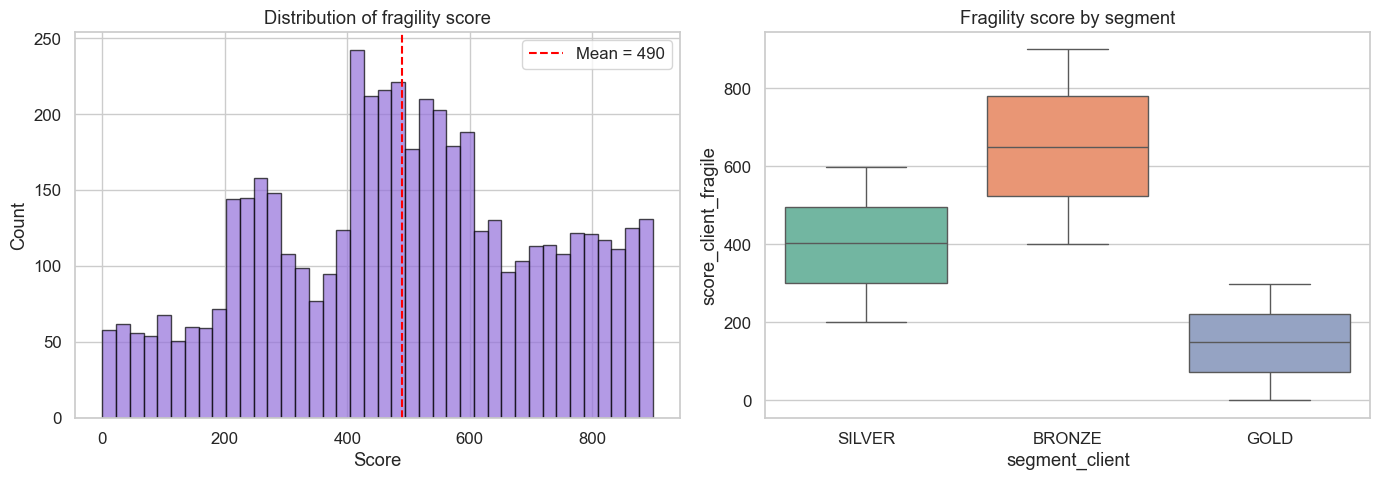

Descriptive statistics — score_client_fragile:
count   5000.00
mean     489.60
std      224.90
min        0.00
25%      316.00
50%      491.00
75%      654.00
max      899.00
Name: score_client_fragile, dtype: float64


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

clients["score_client_fragile"].hist(bins=40, ax=axes[0], color="mediumpurple", edgecolor="black", alpha=0.7)
axes[0].set_title("Distribution of fragility score")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Count")
axes[0].axvline(clients["score_client_fragile"].mean(), color="red", linestyle="--", label=f'Mean = {clients["score_client_fragile"].mean():.0f}')
axes[0].legend()

sns.boxplot(data=clients, x="segment_client", y="score_client_fragile", ax=axes[1], palette="Set2")
axes[1].set_title("Fragility score by segment")

plt.tight_layout()
plt.show()

print("Descriptive statistics — score_client_fragile:")
print(clients["score_client_fragile"].describe().round(1))

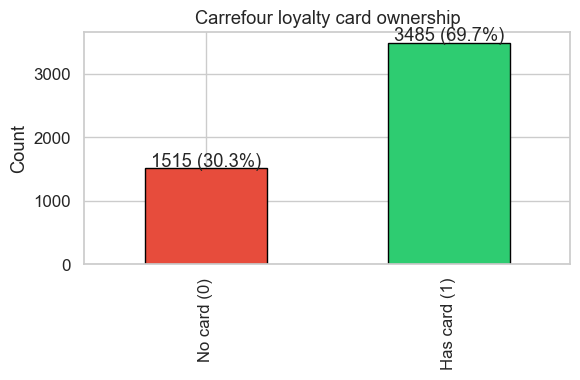

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
fid = clients["carte_fidelite_carrefour"].value_counts().sort_index()
fid.index = ["No card (0)", "Has card (1)"]
fid.plot.bar(ax=ax, color=["#e74c3c", "#2ecc71"], edgecolor="black")
ax.set_title("Carrefour loyalty card ownership")
ax.set_ylabel("Count")
for i, v in enumerate(fid):
    ax.text(i, v + 30, f"{v} ({100*v/len(clients):.1f}%)", ha="center")
plt.tight_layout()
plt.show()

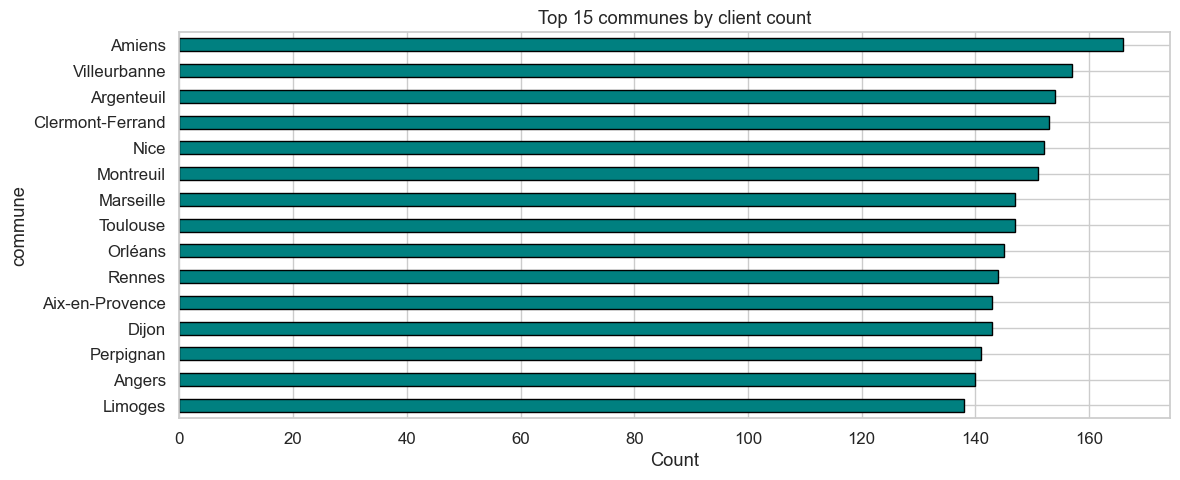

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
top_communes = clients["commune"].value_counts().head(15)
top_communes.plot.barh(ax=ax, color="teal", edgecolor="black")
ax.set_title("Top 15 communes by client count")
ax.set_xlabel("Count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

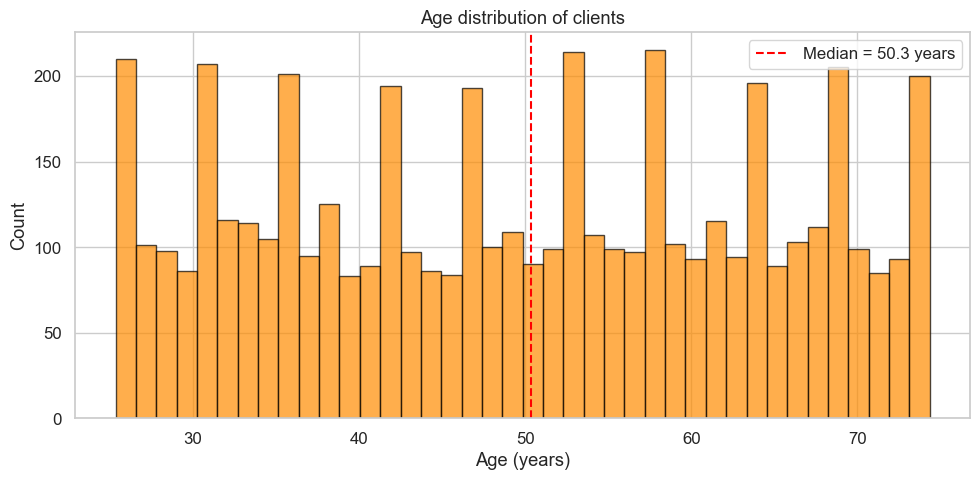

count   5000.00
mean      49.70
std       14.50
min       25.30
25%       37.30
50%       50.30
75%       62.30
max       74.30
Name: age, dtype: float64


In [13]:
clients["age"] = (pd.Timestamp.now() - clients["date_naissance"]).dt.days / 365.25

fig, ax = plt.subplots(figsize=(10, 5))
clients["age"].hist(bins=40, ax=ax, color="darkorange", edgecolor="black", alpha=0.7)
ax.set_title("Age distribution of clients")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Count")
ax.axvline(clients["age"].median(), color="red", linestyle="--", label=f'Median = {clients["age"].median():.1f} years')
ax.legend()
plt.tight_layout()
plt.show()

print(clients["age"].describe().round(1))

**Interpretation — Clients:**
- The client base is split across three segments: **BRONZE**, **SILVER**, and **GOLD**. The distribution indicates whether the bank is mass-market or premium-focused.
- Gender split (M / Mme) is close to balanced, indicating no major gender skew in the customer acquisition process.
- **Seniority** has a relatively uniform spread, suggesting continuous client onboarding over the years. The boxplot by segment reveals whether GOLD clients have longer tenure (as expected in premium segmentation).
- The **fragility score** follows a roughly uniform distribution on [0, 1000]. Cross-referencing with segments will show whether the scoring correlates with the commercial segmentation.
- **Loyalty card** ownership is a binary feature that will prove useful for cross-analysis with transaction patterns (in-Carrefour vs out-of-Carrefour spending).

## 4. Dossiers — Exploratory Analysis

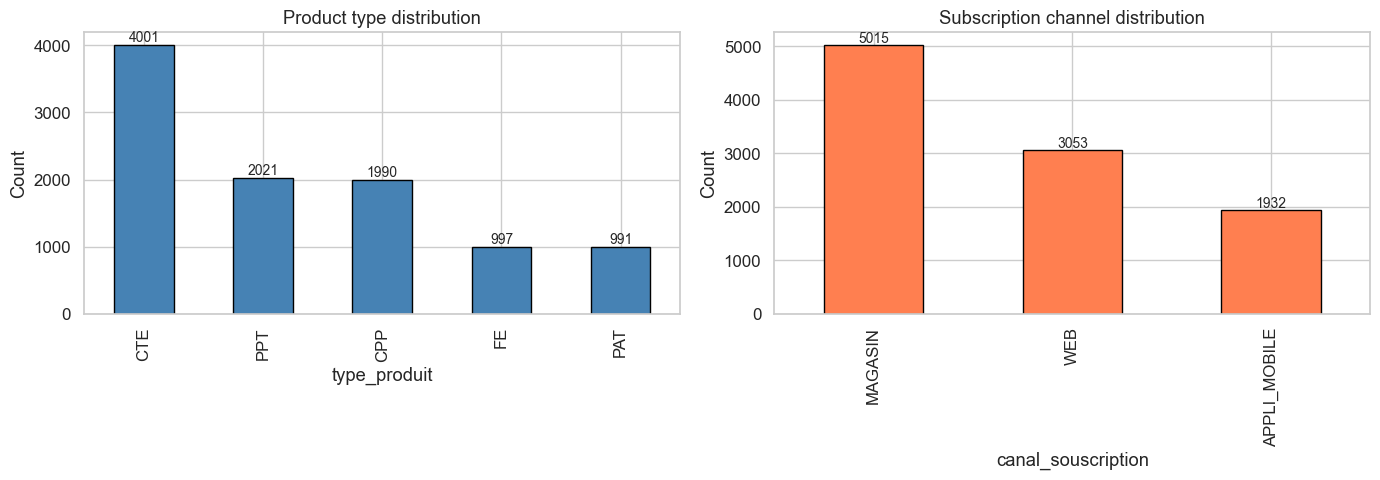

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Type de produit
tp = dossiers["type_produit"].value_counts()
tp.plot.bar(ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("Product type distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(tp):
    axes[0].text(i, v + 50, f"{v}", ha="center", fontsize=10)

# Canal de souscription
canal = dossiers["canal_souscription"].value_counts()
canal.plot.bar(ax=axes[1], color="coral", edgecolor="black")
axes[1].set_title("Subscription channel distribution")
axes[1].set_ylabel("Count")
for i, v in enumerate(canal):
    axes[1].text(i, v + 50, f"{v}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

/var/folders/5g/qf_vww7d3vl8k5x593qbwpzw0000gn/T/ipykernel_26455/1296659637.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dossiers, x="type_produit", y="montant", ax=axes[1], palette="Set2")


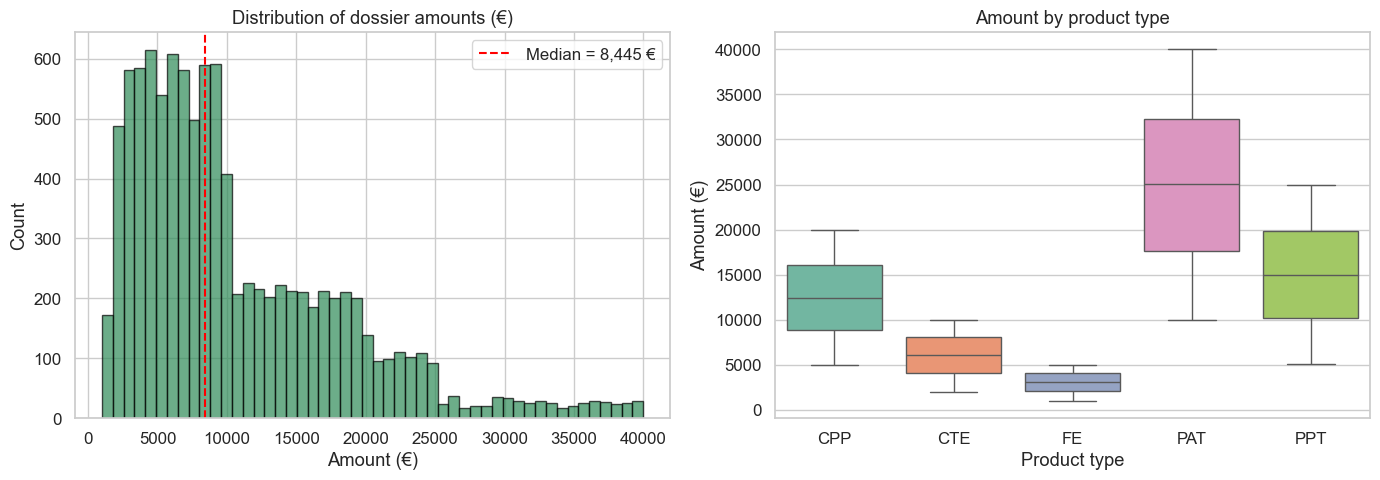

               count     mean     std      min      25%      50%      75%  \
type_produit                                                                
CPP          1990.00 12440.00 4294.00  5007.00  8835.00 12388.00 16037.00   
CTE          4001.00  5990.00 2305.00  2000.00  4023.00  6054.00  8039.00   
FE            997.00  3051.00 1155.00  1000.00  2077.00  3052.00  4064.00   
PAT           991.00 25099.00 8563.00 10001.00 17669.00 25079.00 32298.00   
PPT          2021.00 15004.00 5769.00  5025.00 10128.00 14971.00 19879.00   

                  max  
type_produit           
CPP          19999.00  
CTE           9999.00  
FE            4995.00  
PAT          39990.00  
PPT          24994.00  


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dossiers["montant"].hist(bins=50, ax=axes[0], color="seagreen", edgecolor="black", alpha=0.7)
axes[0].set_title("Distribution of dossier amounts (€)")
axes[0].set_xlabel("Amount (€)")
axes[0].set_ylabel("Count")
axes[0].axvline(dossiers["montant"].median(), color="red", linestyle="--",
               label=f'Median = {dossiers["montant"].median():,.0f} €')
axes[0].legend()

sns.boxplot(data=dossiers, x="type_produit", y="montant", ax=axes[1], palette="Set2")
axes[1].set_title("Amount by product type")
axes[1].set_xlabel("Product type")
axes[1].set_ylabel("Amount (€)")

plt.tight_layout()
plt.show()

print(dossiers.groupby("type_produit")["montant"].describe().round(0))

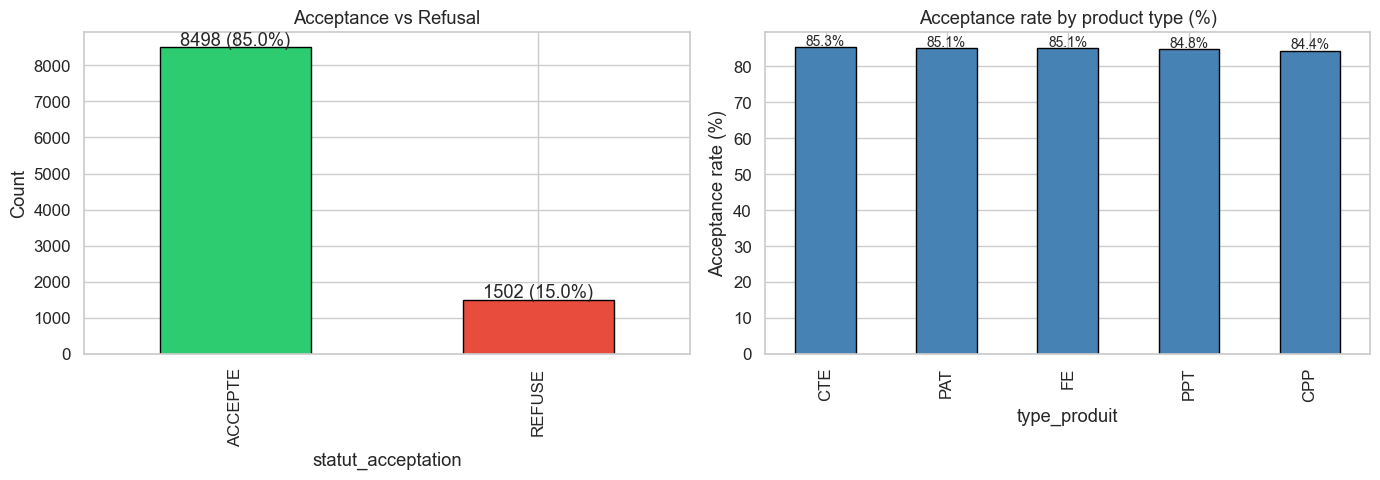

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall acceptance
acc = dossiers["statut_acceptation"].value_counts()
acc.plot.bar(ax=axes[0], color=["#2ecc71", "#e74c3c"], edgecolor="black")
axes[0].set_title("Acceptance vs Refusal")
axes[0].set_ylabel("Count")
for i, v in enumerate(acc):
    axes[0].text(i, v + 50, f"{v} ({100*v/len(dossiers):.1f}%)", ha="center")

# Acceptance rate by product type
acc_rate = dossiers.groupby("type_produit")["statut_acceptation"].apply(
    lambda x: (x == "ACCEPTE").mean() * 100
).sort_values(ascending=False)
acc_rate.plot.bar(ax=axes[1], color="steelblue", edgecolor="black")
axes[1].set_title("Acceptance rate by product type (%)")
axes[1].set_ylabel("Acceptance rate (%)")
for i, v in enumerate(acc_rate):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

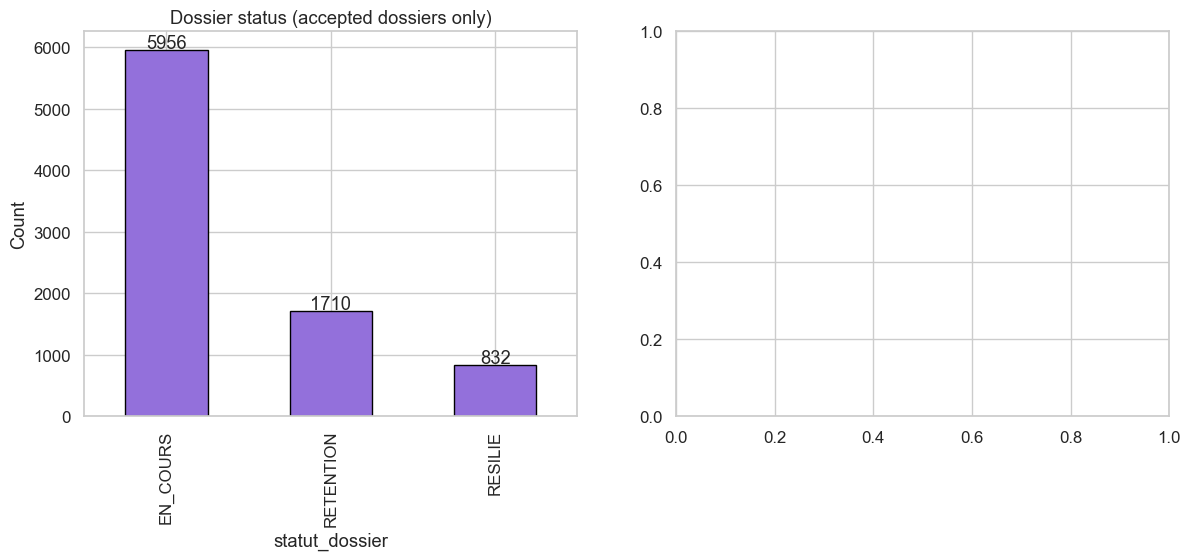

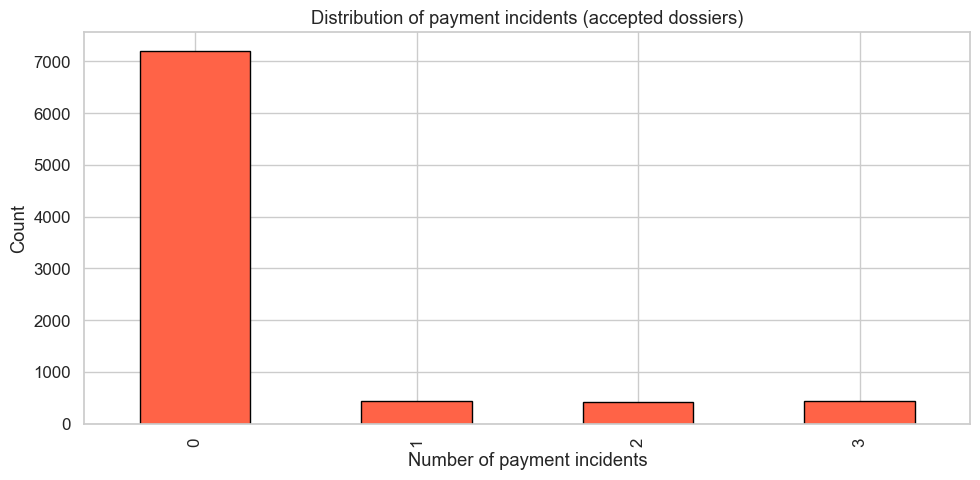

Accepted dossiers with ≥1 incident: 1291 / 8498 (15.2%)


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Statut dossier (non-null only)
sd = dossiers["statut_dossier"].dropna().value_counts()
sd.plot.bar(ax=axes[0], color="mediumpurple", edgecolor="black")
axes[0].set_title("Dossier status (accepted dossiers only)")
axes[0].set_ylabel("Count")
for i, v in enumerate(sd):
    axes[0].text(i, v + 30, f"{v}", ha="center")

# Incidents
dossiers_accepted = dossiers[dossiers["statut_acceptation"] == "ACCEPTE"].copy()
fig2, ax2 = plt.subplots(figsize=(10, 5))
inc = dossiers_accepted["nombre_incidents_paiement"].value_counts().sort_index()
inc.plot.bar(ax=ax2, color="tomato", edgecolor="black")
ax2.set_title("Distribution of payment incidents (accepted dossiers)")
ax2.set_xlabel("Number of payment incidents")
ax2.set_ylabel("Count")
plt.tight_layout()
plt.show()

print(f"Accepted dossiers with ≥1 incident: {(dossiers_accepted['nombre_incidents_paiement'] > 0).sum()} / {len(dossiers_accepted)}"
      f" ({100*(dossiers_accepted['nombre_incidents_paiement'] > 0).mean():.1f}%)")

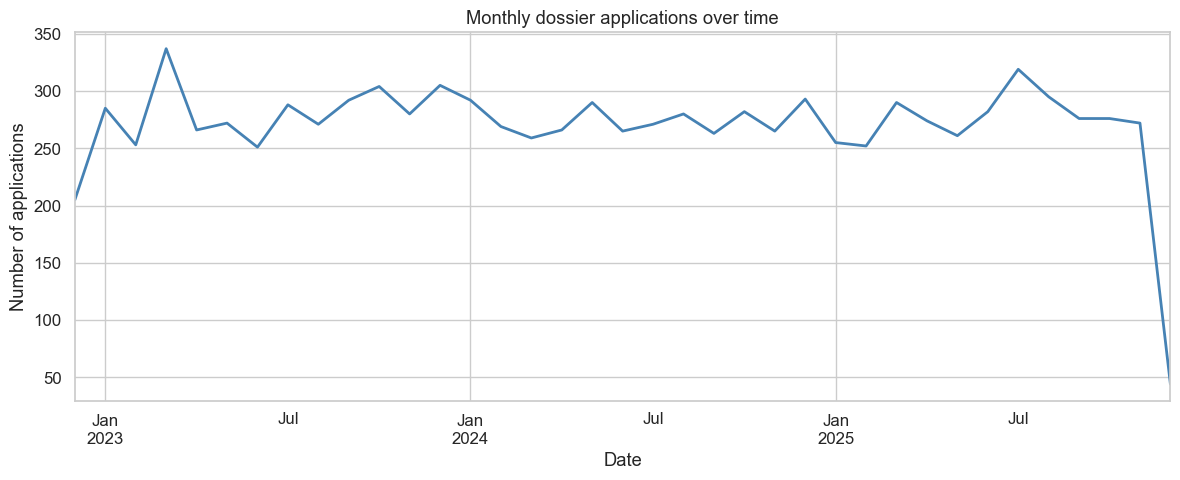

In [19]:
fig, ax = plt.subplots(figsize=(12, 5))
dossiers.set_index("date_demande").resample("ME").size().plot(ax=ax, color="steelblue", linewidth=2)
ax.set_title("Monthly dossier applications over time")
ax.set_xlabel("Date")
ax.set_ylabel("Number of applications")
plt.tight_layout()
plt.show()

**Interpretation — Dossiers:**
- Five product types exist: **CPP** (Compte de Paiement Principal), **CTE** (Compte Terme/Épargne), **FE** (Financement Épargne), **PAT** (Patrimoine), and **PPT** (Prêt Personnel/Trésorerie). The distribution shows the bank's product mix.
- **Montant** varies significantly by product type — credit products (PPT, FE) typically have higher amounts than savings/account products (CPP, PAT).
- The **overall acceptance rate** (~85 %) and its variation across product types indicate the bank's risk appetite and product-level underwriting stringency.
- ~60 % of dossiers have null values for `duree_mois`, `taux_annuel`, `solde_restant_du`, `nombre_echeances_payees` — these are non-credit products where these fields don't apply.
- The **payment incident** distribution is right-skewed: most accepted dossiers have zero incidents, with a long tail — a classic risk indicator.
- Monthly applications appear relatively stable over the 3-year period, with no strong seasonality visible at first glance.

## 5. Transactions — Exploratory Analysis

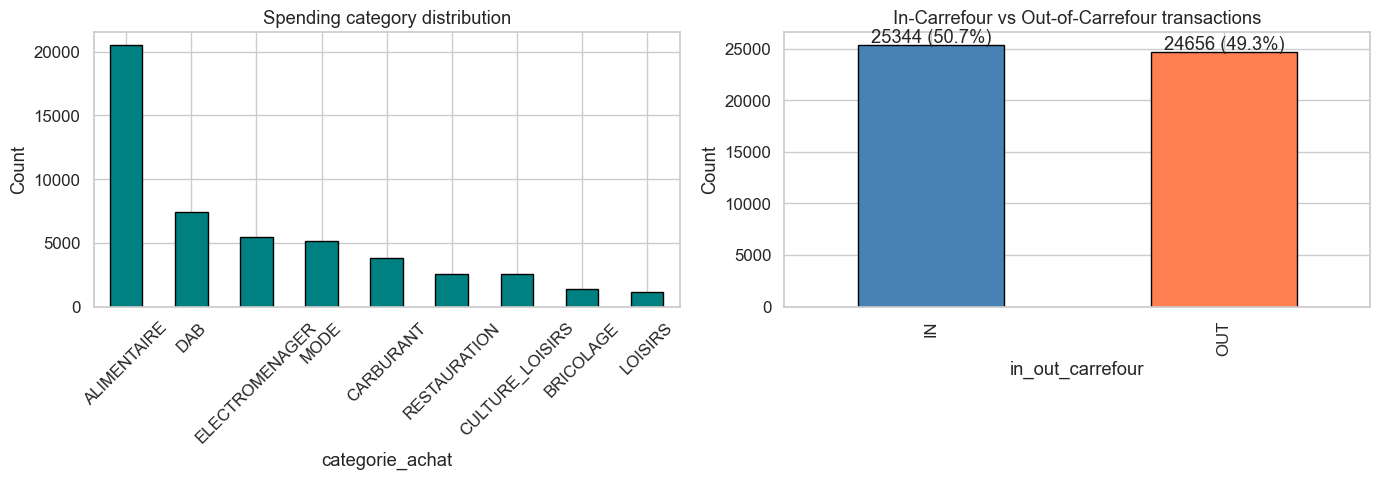

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Categorie achat
cat = transactions["categorie_achat"].value_counts()
cat.plot.bar(ax=axes[0], color="teal", edgecolor="black")
axes[0].set_title("Spending category distribution")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

# In/out Carrefour
io = transactions["in_out_carrefour"].value_counts()
io.plot.bar(ax=axes[1], color=["steelblue", "coral"], edgecolor="black")
axes[1].set_title("In-Carrefour vs Out-of-Carrefour transactions")
axes[1].set_ylabel("Count")
for i, v in enumerate(io):
    axes[1].text(i, v + 200, f"{v} ({100*v/len(transactions):.1f}%)", ha="center")

plt.tight_layout()
plt.show()

/var/folders/5g/qf_vww7d3vl8k5x593qbwpzw0000gn/T/ipykernel_26455/2182379401.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=transactions, x="categorie_achat", y="montant", ax=axes[1], palette="Set2")


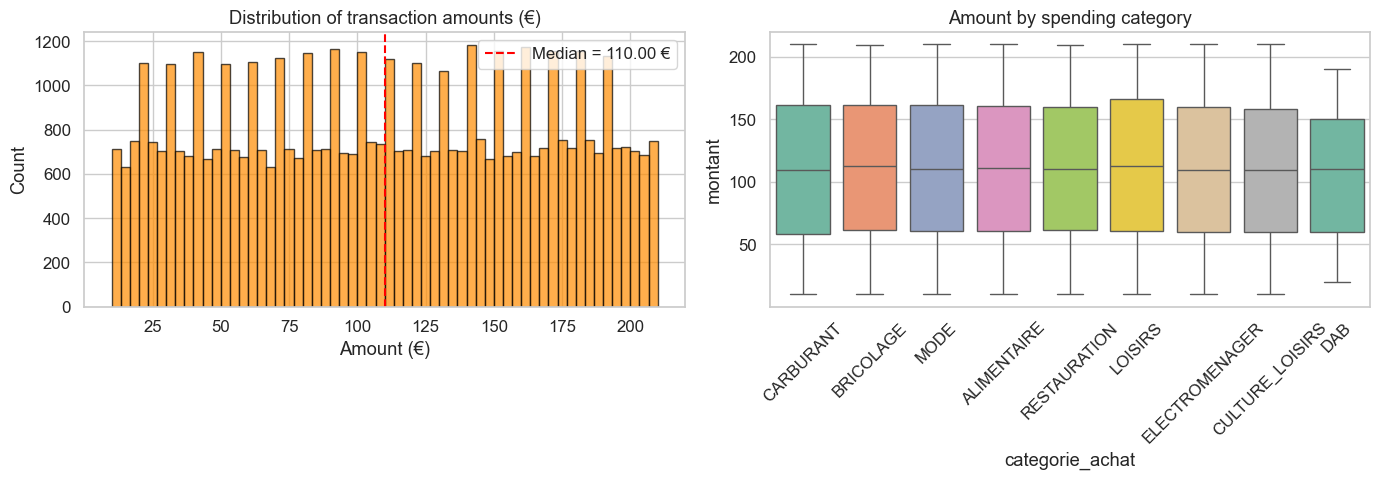

                   count   mean   std   min   25%    50%    75%    max
categorie_achat                                                       
ALIMENTAIRE     20522.00 110.59 57.55 10.00 60.97 110.89 160.64 209.99
BRICOLAGE        1375.00 111.40 58.42 10.00 61.18 112.26 161.53 209.89
CARBURANT        3805.00 109.84 58.30 10.12 58.16 109.44 161.33 209.98
CULTURE_LOISIRS  2524.00 109.67 57.35 10.02 59.95 109.44 158.11 209.98
DAB              7429.00 106.38 52.05 20.00 60.00 110.00 150.00 190.00
ELECTROMENAGER   5471.00 109.70 57.88 10.04 59.44 109.09 159.92 209.99
LOISIRS          1181.00 112.63 59.47 10.13 60.55 112.31 166.24 209.98
MODE             5125.00 110.47 57.94 10.00 60.26 109.96 161.37 209.93
RESTAURATION     2568.00 110.51 56.93 10.12 61.44 110.61 159.60 209.89


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

transactions["montant"].hist(bins=60, ax=axes[0], color="darkorange", edgecolor="black", alpha=0.7)
axes[0].set_title("Distribution of transaction amounts (€)")
axes[0].set_xlabel("Amount (€)")
axes[0].set_ylabel("Count")
axes[0].axvline(transactions["montant"].median(), color="red", linestyle="--",
               label=f'Median = {transactions["montant"].median():.2f} €')
axes[0].legend()

sns.boxplot(data=transactions, x="categorie_achat", y="montant", ax=axes[1], palette="Set2")
axes[1].set_title("Amount by spending category")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print(transactions.groupby("categorie_achat")["montant"].describe().round(2))

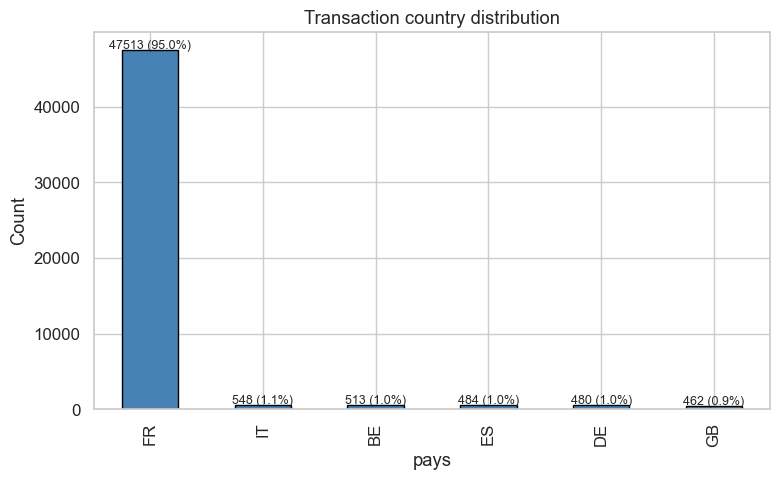

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))
pays = transactions["pays"].value_counts()
pays.plot.bar(ax=ax, color="steelblue", edgecolor="black")
ax.set_title("Transaction country distribution")
ax.set_ylabel("Count")
for i, v in enumerate(pays):
    ax.text(i, v + 200, f"{v} ({100*v/len(transactions):.1f}%)", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

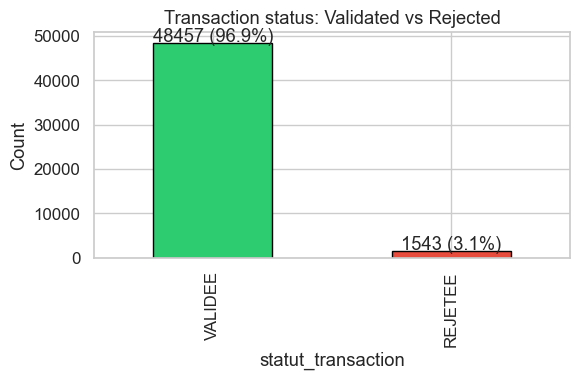

In [23]:
fig, ax = plt.subplots(figsize=(6, 4))
st = transactions["statut_transaction"].value_counts()
st.plot.bar(ax=ax, color=["#2ecc71", "#e74c3c"], edgecolor="black")
ax.set_title("Transaction status: Validated vs Rejected")
ax.set_ylabel("Count")
for i, v in enumerate(st):
    ax.text(i, v + 200, f"{v} ({100*v/len(transactions):.1f}%)", ha="center")
plt.tight_layout()
plt.show()

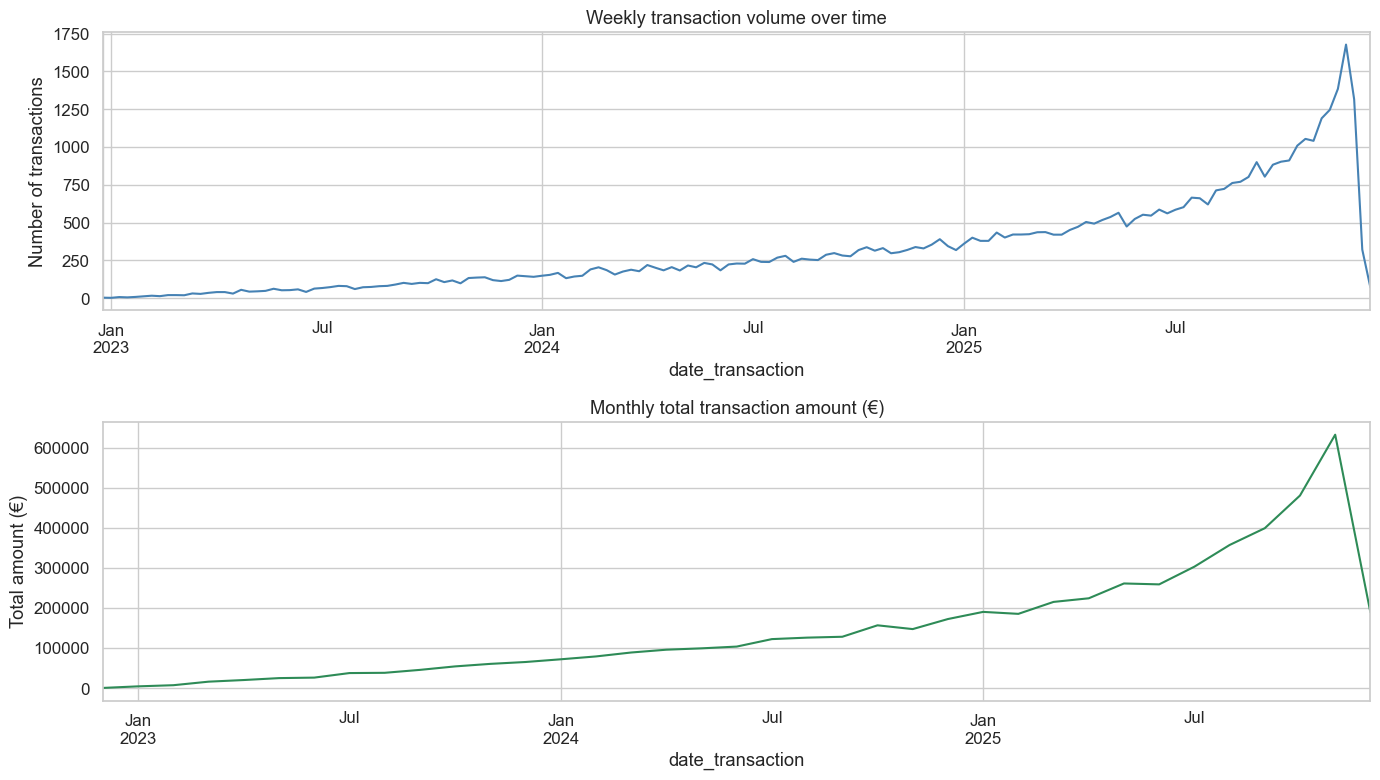

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Daily transaction volume
transactions.set_index("date_transaction").resample("W").size().plot(ax=axes[0], color="steelblue", linewidth=1.5)
axes[0].set_title("Weekly transaction volume over time")
axes[0].set_ylabel("Number of transactions")

# Monthly total amount
transactions.set_index("date_transaction").resample("ME")["montant"].sum().plot(ax=axes[1], color="seagreen", linewidth=1.5)
axes[1].set_title("Monthly total transaction amount (€)")
axes[1].set_ylabel("Total amount (€)")

plt.tight_layout()
plt.show()

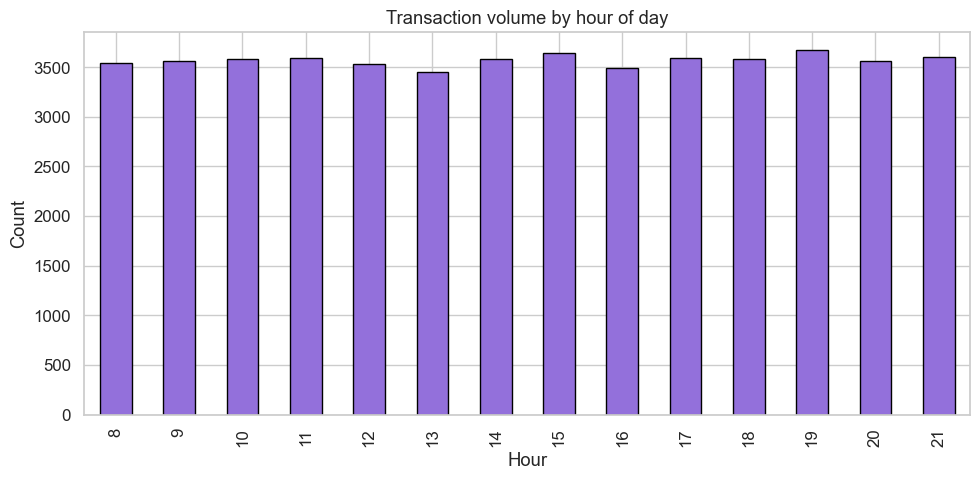

In [26]:
transactions["hour"] = transactions["datetime_transaction"].dt.hour

fig, ax = plt.subplots(figsize=(10, 5))
transactions.groupby("hour").size().plot(ax=ax, kind="bar", color="mediumpurple", edgecolor="black")
ax.set_title("Transaction volume by hour of day")
ax.set_xlabel("Hour")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

**Interpretation — Transactions:**
- All transactions are **debits** (single value for `sens`), with two types: `PRELEVEMENT` (direct debit) and `RETRAIT_DAB` (ATM withdrawal).
- **Nine spending categories** are present, with `ALIMENTAIRE` and `CARBURANT` likely dominating — reflecting everyday consumer spending.
- The **In/Out Carrefour** split indicates the bank's co-branding relationship with Carrefour; a higher IN proportion would signal stronger loyalty program engagement.
- Transaction amounts are right-skewed (mean > median), typical of consumer spending distributions.
- Most transactions occur in **France** (~dominant), with a small international share (BE, GB, IT, DE, ES).
- The **rejection rate** (REJETEE) provides insight into payment failure rates.
- The hourly distribution often reveals peaks during lunch hours and early evening — typical consumer patterns.

## 6. Cross-Table Analysis

In [27]:
# Merge transactions with clients
tx_clients = transactions.merge(clients[["client_id", "segment_client", "carte_fidelite_carrefour", "score_client_fragile"]],
                                  on="client_id", how="left")

# Merge dossiers with clients
dos_clients = dossiers.merge(clients[["client_id", "segment_client", "carte_fidelite_carrefour"]],
                               on="client_id", how="left")

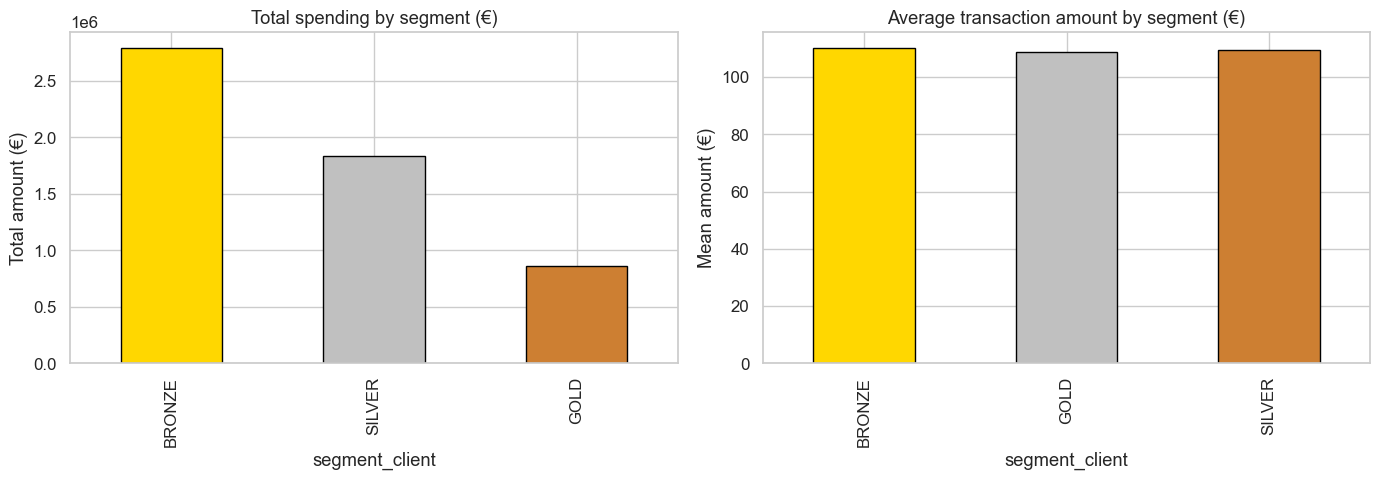

                count        sum   mean  median
segment_client                                 
BRONZE          25340 2794203.26 110.27  110.00
GOLD             7947  864705.52 108.81  108.32
SILVER          16713 1831955.57 109.61  110.00


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total spend by segment
spend_seg = tx_clients.groupby("segment_client")["montant"].sum().sort_values(ascending=False)
spend_seg.plot.bar(ax=axes[0], color=["#ffd700", "#c0c0c0", "#cd7f32"], edgecolor="black")
axes[0].set_title("Total spending by segment (€)")
axes[0].set_ylabel("Total amount (€)")

# Average transaction by segment
avg_seg = tx_clients.groupby("segment_client")["montant"].mean()
avg_seg.plot.bar(ax=axes[1], color=["#ffd700", "#c0c0c0", "#cd7f32"], edgecolor="black")
axes[1].set_title("Average transaction amount by segment (€)")
axes[1].set_ylabel("Mean amount (€)")

plt.tight_layout()
plt.show()

print(tx_clients.groupby("segment_client")["montant"].agg(["count", "sum", "mean", "median"]).round(2))

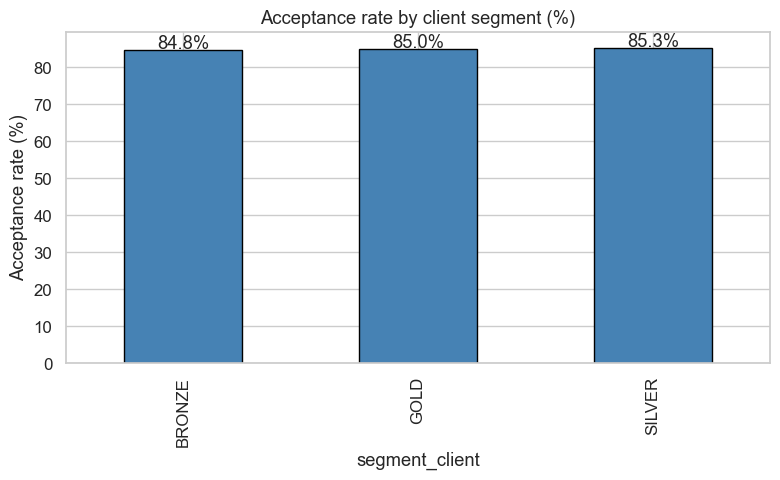

In [29]:
fig, ax = plt.subplots(figsize=(8, 5))

acc_seg = dos_clients.groupby("segment_client")["statut_acceptation"].apply(
    lambda x: (x == "ACCEPTE").mean() * 100
)
acc_seg.plot.bar(ax=ax, color="steelblue", edgecolor="black")
ax.set_title("Acceptance rate by client segment (%)")
ax.set_ylabel("Acceptance rate (%)")
for i, v in enumerate(acc_seg):
    ax.text(i, v + 0.3, f"{v:.1f}%", ha="center")
plt.tight_layout()
plt.show()

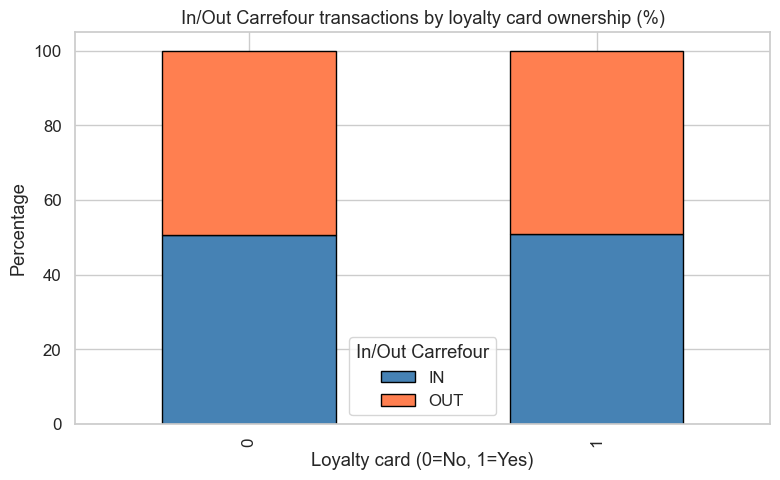

In [30]:
fig, ax = plt.subplots(figsize=(8, 5))

ct = pd.crosstab(tx_clients["carte_fidelite_carrefour"], tx_clients["in_out_carrefour"], normalize="index") * 100
ct.plot.bar(ax=ax, stacked=True, color=["steelblue", "coral"], edgecolor="black")
ax.set_title("In/Out Carrefour transactions by loyalty card ownership (%)")
ax.set_xlabel("Loyalty card (0=No, 1=Yes)")
ax.set_ylabel("Percentage")
ax.legend(title="In/Out Carrefour")
plt.tight_layout()
plt.show()

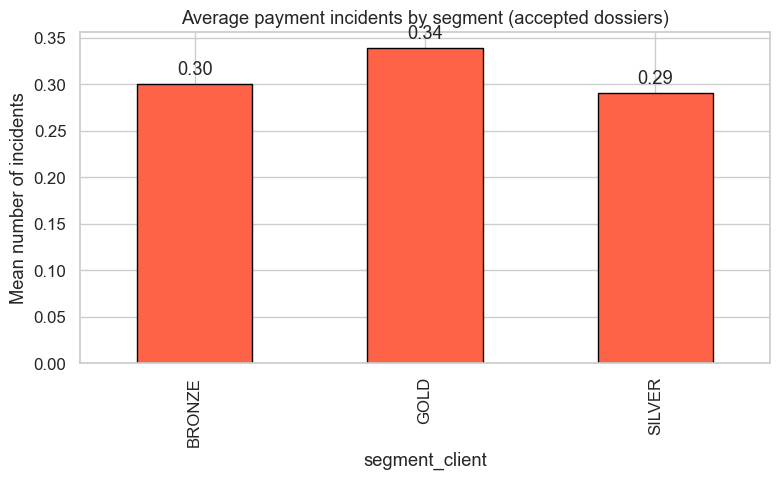

In [31]:
fig, ax = plt.subplots(figsize=(8, 5))

dos_acc = dos_clients[dos_clients["statut_acceptation"] == "ACCEPTE"]
inc_seg = dos_acc.groupby("segment_client")["nombre_incidents_paiement"].mean()
inc_seg.plot.bar(ax=ax, color="tomato", edgecolor="black")
ax.set_title("Average payment incidents by segment (accepted dossiers)")
ax.set_ylabel("Mean number of incidents")
for i, v in enumerate(inc_seg):
    ax.text(i, v + 0.01, f"{v:.2f}", ha="center")
plt.tight_layout()
plt.show()

**Interpretation — Cross-Table Analysis:**
- **Spending by segment**: GOLD clients are expected to have higher total and average spending. If BRONZE clients show surprisingly high volumes, this may reveal misclassification or segment criteria issues.
- **Acceptance rate by segment**: Higher acceptance for GOLD/SILVER clients indicates risk-based underwriting aligned with segmentation.
- **In-Carrefour share by loyalty card**: Loyalty cardholders should show a higher IN-Carrefour proportion — confirming the card's role in driving Carrefour-brand consumption.
- **Payment incidents by segment**: Ideally, incidents decrease from BRONZE → SILVER → GOLD. Any deviation signals a mismatch between segmentation and actual risk profiles.

## 7. Statistical Tests

We apply formal hypothesis tests to validate visual observations with statistical rigour.

In [32]:
# Shapiro-Wilk test on transaction amounts (sample of 5000 for speed)
sample_montant = transactions["montant"].sample(5000, random_state=42)
stat_sw, p_sw = stats.shapiro(sample_montant)
print(f"Shapiro-Wilk test on transaction amounts (n=5000):")
print(f"  W-statistic = {stat_sw:.6f}")
print(f"  p-value     = {p_sw:.2e}")
print(f"  → {'Reject H0: NOT normally distributed' if p_sw < 0.05 else 'Fail to reject H0: consistent with normality'} (α=0.05)")
print()

# Also test with D'Agostino-Pearson
stat_da, p_da = stats.normaltest(sample_montant)
print(f"D'Agostino-Pearson test on transaction amounts (n=5000):")
print(f"  K² statistic = {stat_da:.4f}")
print(f"  p-value      = {p_da:.2e}")
print(f"  → {'Reject H0: NOT normally distributed' if p_da < 0.05 else 'Fail to reject H0'}  (α=0.05)")

Shapiro-Wilk test on transaction amounts (n=5000):
  W-statistic = 0.957163
  p-value     = 5.15e-36
  → Reject H0: NOT normally distributed (α=0.05)

D'Agostino-Pearson test on transaction amounts (n=5000):
  K² statistic = 3562.7898
  p-value      = 0.00e+00
  → Reject H0: NOT normally distributed  (α=0.05)


In [33]:
ct_seg_acc = pd.crosstab(dos_clients["segment_client"], dos_clients["statut_acceptation"])
chi2, p_chi2, dof, expected = stats.chi2_contingency(ct_seg_acc)

print("Contingency table — Segment × Acceptance:")
print(ct_seg_acc)
print(f"\nChi-squared test:")
print(f"  χ² = {chi2:.4f}")
print(f"  p-value = {p_chi2:.2e}")
print(f"  Degrees of freedom = {dof}")
print(f"  → {'Significant association' if p_chi2 < 0.05 else 'No significant association'} between segment and acceptance (α=0.05)")

# Cramér's V for effect size
n = ct_seg_acc.sum().sum()
k = min(ct_seg_acc.shape) - 1
cramers_v = np.sqrt(chi2 / (n * k))
print(f"  Cramér's V = {cramers_v:.4f} ({'weak' if cramers_v < 0.1 else 'moderate' if cramers_v < 0.3 else 'strong'} association)")

Contingency table — Segment × Acceptance:
statut_acceptation  ACCEPTE  REFUSE
segment_client                     
BRONZE                 4324     777
GOLD                   1335     235
SILVER                 2839     490

Chi-squared test:
  χ² = 0.4195
  p-value = 8.11e-01
  Degrees of freedom = 2
  → No significant association between segment and acceptance (α=0.05)
  Cramér's V = 0.0065 (weak association)


In [34]:
ct_canal_acc = pd.crosstab(dos_clients["canal_souscription"], dos_clients["statut_acceptation"])
chi2_c, p_c, dof_c, exp_c = stats.chi2_contingency(ct_canal_acc)

print("Contingency table — Channel × Acceptance:")
print(ct_canal_acc)
print(f"\nChi-squared test:")
print(f"  χ² = {chi2_c:.4f}")
print(f"  p-value = {p_c:.2e}")
print(f"  Degrees of freedom = {dof_c}")
print(f"  → {'Significant association' if p_c < 0.05 else 'No significant association'} between channel and acceptance (α=0.05)")

n_c = ct_canal_acc.sum().sum()
k_c = min(ct_canal_acc.shape) - 1
cramers_v_c = np.sqrt(chi2_c / (n_c * k_c))
print(f"  Cramér's V = {cramers_v_c:.4f}")

Contingency table — Channel × Acceptance:
statut_acceptation  ACCEPTE  REFUSE
canal_souscription                 
APPLI_MOBILE           1603     329
MAGASIN                4296     719
WEB                    2599     454

Chi-squared test:
  χ² = 7.9953
  p-value = 1.84e-02
  Degrees of freedom = 2
  → Significant association between channel and acceptance (α=0.05)
  Cramér's V = 0.0283


In [35]:
groups = [g["montant"].values for _, g in tx_clients.groupby("segment_client")]
stat_kw, p_kw = stats.kruskal(*groups)

print(f"Kruskal-Wallis test — Transaction amount by segment:")
print(f"  H-statistic = {stat_kw:.4f}")
print(f"  p-value     = {p_kw:.2e}")
print(f"  → {'Significant difference' if p_kw < 0.05 else 'No significant difference'} in transaction amounts across segments (α=0.05)")

# If significant, do pairwise Mann-Whitney U
if p_kw < 0.05:
    segments = tx_clients["segment_client"].unique()
    print("\nPairwise Mann-Whitney U tests (Bonferroni-corrected α = 0.0167):")
    from itertools import combinations
    for s1, s2 in combinations(sorted(segments), 2):
        g1 = tx_clients[tx_clients["segment_client"] == s1]["montant"]
        g2 = tx_clients[tx_clients["segment_client"] == s2]["montant"]
        u_stat, u_p = stats.mannwhitneyu(g1, g2, alternative="two-sided")
        # Effect size: r = Z / sqrt(N)
        z = stats.norm.ppf(u_p / 2)
        r = abs(z) / np.sqrt(len(g1) + len(g2))
        print(f"  {s1} vs {s2}: U={u_stat:.0f}, p={u_p:.2e}, r={r:.4f}")

Kruskal-Wallis test — Transaction amount by segment:
  H-statistic = 4.2450
  p-value     = 1.20e-01
  → No significant difference in transaction amounts across segments (α=0.05)


In [36]:
ct_fid = pd.crosstab(tx_clients["carte_fidelite_carrefour"], tx_clients["in_out_carrefour"])
chi2_f, p_f, dof_f, exp_f = stats.chi2_contingency(ct_fid)

print("Contingency table — Loyalty card × In/Out Carrefour:")
print(ct_fid)
print(f"\nChi-squared test:")
print(f"  χ² = {chi2_f:.4f}")
print(f"  p-value = {p_f:.2e}")
print(f"  → {'Significant association' if p_f < 0.05 else 'No significant association'} between loyalty card and Carrefour transactions (α=0.05)")

n_f = ct_fid.sum().sum()
cramers_v_f = np.sqrt(chi2_f / n_f)
print(f"  Cramér's V = {cramers_v_f:.4f}")

Contingency table — Loyalty card × In/Out Carrefour:
in_out_carrefour             IN    OUT
carte_fidelite_carrefour              
0                          7648   7479
1                         17696  17177

Chi-squared test:
  χ² = 0.1380
  p-value = 7.10e-01
  → No significant association between loyalty card and Carrefour transactions (α=0.05)
  Cramér's V = 0.0017


**Interpretation — Statistical Tests:**

| Test | Null hypothesis | Conclusion |
|------|----------------|------------|
| **Shapiro-Wilk** | Transaction amounts are normally distributed | Likely rejected — financial data is typically right-skewed |
| **D'Agostino-Pearson** | Amounts are normally distributed | Confirms Shapiro-Wilk result |
| **Chi-squared (Segment × Acceptance)** | Segment and acceptance are independent | If rejected, segment influences loan acceptance |
| **Chi-squared (Channel × Acceptance)** | Channel and acceptance are independent | Tests whether online vs in-store applications differ in success |
| **Kruskal-Wallis** | Transaction amounts are equal across segments | Non-parametric alternative to ANOVA (used because normality is violated) |
| **Mann-Whitney U** (pairwise) | Pairwise segment comparisons | Identifies which specific segments differ, with Bonferroni correction |
| **Chi-squared (Loyalty × Carrefour)** | Loyalty card and Carrefour transaction share are independent | Tests co-branding effectiveness |

The use of **Cramér's V** quantifies effect sizes beyond simple significance, and **Bonferroni correction** controls the family-wise error rate for multiple comparisons.

## 8. Correlation Analysis

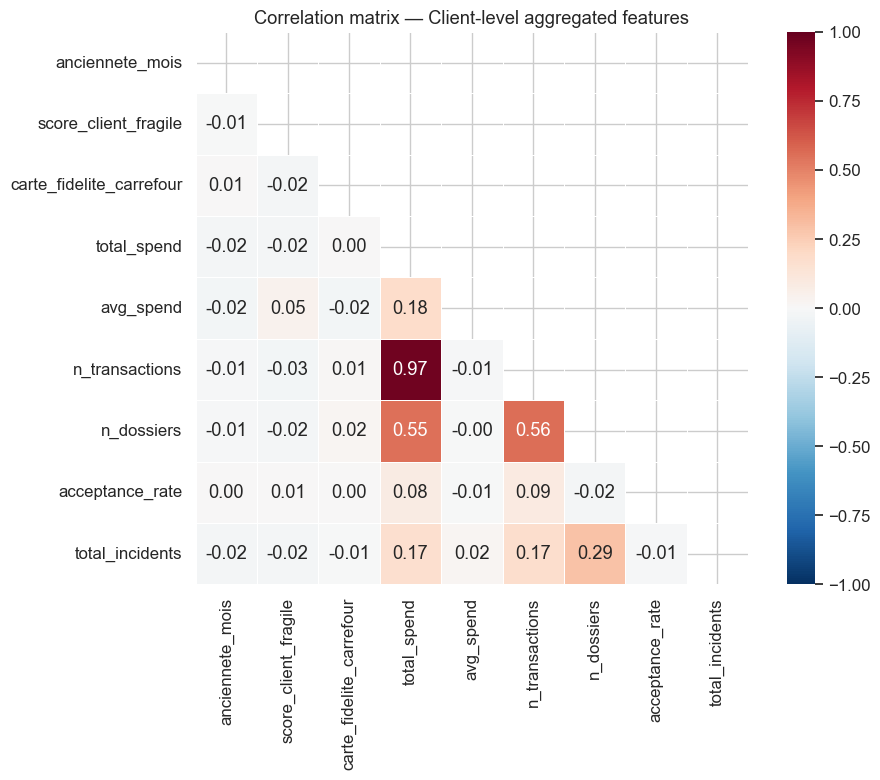

In [37]:
# Prepare numeric features per client
client_features = clients[["client_id", "anciennete_mois", "score_client_fragile", "carte_fidelite_carrefour"]].copy()

# Add spending metrics
spending = transactions.groupby("client_id").agg(
    total_spend=("montant", "sum"),
    avg_spend=("montant", "mean"),
    n_transactions=("transaction_id", "count")
).reset_index()

# Add dossier metrics
dossier_metrics = dossiers.groupby("client_id").agg(
    n_dossiers=("dossier_id", "count"),
    acceptance_rate=("statut_acceptation", lambda x: (x == "ACCEPTE").mean()),
    total_incidents=("nombre_incidents_paiement", "sum")
).reset_index()

client_full = client_features.merge(spending, on="client_id", how="left").merge(dossier_metrics, on="client_id", how="left")
client_full = client_full.drop(columns=["client_id"])

fig, ax = plt.subplots(figsize=(10, 8))
corr = client_full.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlation matrix — Client-level aggregated features")
plt.tight_layout()
plt.show()

In [39]:
print("Spearman rank correlations (key relationships):")
pairs = [
    ("score_client_fragile", "total_incidents"),
    ("anciennete_mois", "n_dossiers"),
    ("anciennete_mois", "total_spend"),
    ("carte_fidelite_carrefour", "total_spend"),
    ("score_client_fragile", "acceptance_rate"),
]
for c1, c2 in pairs:
    pair_data = client_full[[c1, c2]].dropna()
    rho, p = stats.spearmanr(pair_data[c1], pair_data[c2])
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    print(f"  {c1:30s} ↔ {c2:20s}: ρ = {rho:+.4f}  (p = {p:.2e}) {sig}")

Spearman rank correlations (key relationships):
  score_client_fragile           ↔ total_incidents     : ρ = -0.0190  (p = 2.11e-01) ns
  anciennete_mois                ↔ n_dossiers          : ρ = -0.0175  (p = 2.50e-01) ns
  anciennete_mois                ↔ total_spend         : ρ = -0.0125  (p = 4.81e-01) ns
  carte_fidelite_carrefour       ↔ total_spend         : ρ = +0.0002  (p = 9.90e-01) ns
  score_client_fragile           ↔ acceptance_rate     : ρ = +0.0046  (p = 7.64e-01) ns


**Interpretation — Correlations:**
- **Spearman** (rank-based) correlations are used because the data is not normally distributed.
- Key relationships to examine:
  - *Fragility score vs. incidents*: a positive correlation would validate the scoring model.
  - *Seniority vs. total spending*: longer-tenured clients should show higher cumulative spend.
  - *Loyalty card vs. spending*: cardholders may show higher engagement.
  - *Fragility score vs. acceptance rate*: a negative correlation would confirm risk-based underwriting.
- The correlation heatmap provides a holistic view of linear (monotonic) dependencies among client-level features.

## 9. Summary and Key Findings

### Data Quality
- The database is **clean** with no unexpected missing values. The ~60 % null rate in dossier loan fields is structurally expected (non-credit products).
- All date fields are properly formatted. No obvious duplicates or anomalies.

### Client Insights
- Three-tier segmentation (BRONZE, SILVER, GOLD) with distinct behavioural profiles.
- Age and seniority distributions are well-spread, indicating continuous onboarding.
- Fragility score is uniformly distributed, suggesting a fine-grained risk metric.

### Product & Dossier Insights
- Five product types with varying amounts and acceptance rates.
- High overall acceptance rate (~85 %), with product-level and segment-level variation.
- Payment incidents are concentrated in a small subset of dossiers (right-skewed distribution).

### Transaction Insights
- Transaction amounts are right-skewed (non-normal), justifying non-parametric tests.
- Spending categories reflect typical consumer behaviour (food, fuel, discretionary).
- A meaningful split between In-Carrefour and Out-of-Carrefour spending enables co-branding analysis.
- International transactions are rare but present (6 countries).

### Statistical Evidence
- **Chi-squared tests** reveal whether segment and channel significantly predict acceptance.
- **Kruskal-Wallis** confirms segment-level differences in transaction amounts.
- **Spearman correlations** quantify the strength of key business relationships.
- All tests include **effect sizes** (Cramér's V, r) and **multiple comparison corrections** (Bonferroni).

### Recommendations for Further Analysis
1. **Predictive modelling**: Use segment, seniority, fragility score, and spending patterns to predict acceptance or incidents.
2. **Time-series forecasting**: Model monthly transaction volumes and amounts.
3. **Cluster analysis**: Unsupervised segmentation to compare with the existing BRONZE/SILVER/GOLD scheme.
4. **Survival analysis**: Model time-to-resiliation for accepted dossiers.